<a href="https://colab.research.google.com/github/AyushFegade/ayushfegade/blob/main/ayushfegade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots
%matplotlib inline
sns.set_style("whitegrid")

In [60]:
df = pd.read_csv("penguins_size.csv")

# Display first 5 rows
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [61]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Dataset information
print("\nDataset Info:")
df.info()

Shape: (344, 7)

Columns:
Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

Data Types:
species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             343 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  341 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [62]:
# Statistical summary
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,341.000000,342.000000
mean,43.921930,17.151170,200.873900,4201.754386
std,5.459584,1.974793,14.061585,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [63]:
# For categorical columns
df.describe(include='object')

,species,island,sex
count,344,343,334
unique,4,3,3
top,Adelie,Biscoe,MALE
freq,151,167,168


In [64]:
# Value counts
print(df['species'].value_counts())

print(df['island'].value_counts())

print(df['sex'].value_counts())

species
Adelie       151
Gentoo       123
Chinstrap     67
?              3
Name: count, dtype: int64
island
Biscoe       167
Dream        124
Torgersen     52
Name: count, dtype: int64
sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64


In [65]:
# Missing values
df.isnull().sum()

,0
species,0
island,1
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,3
body_mass_g,2
sex,10


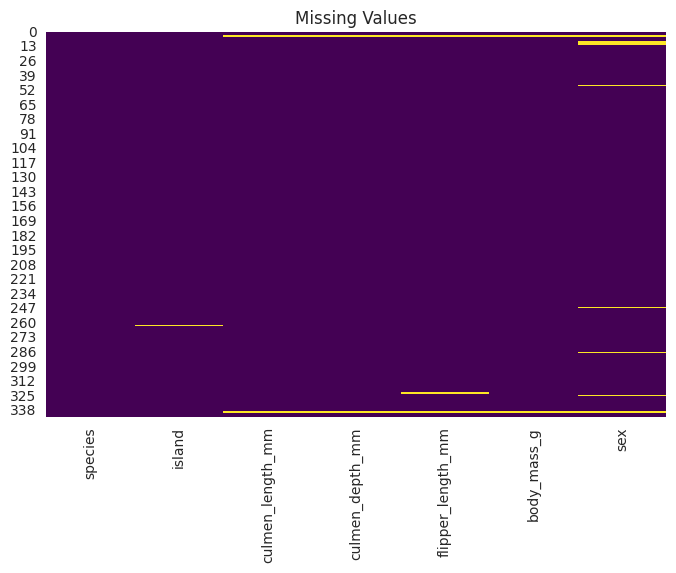

In [66]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values")
plt.show()

In [67]:
# Data Cleaning
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Duplicate Rows: 0
Shape after removing duplicates: (344, 7)


In [68]:
# Replace invalid values with NaN
df['species'] = df['species'].replace('?', np.nan)
df['sex'] = df['sex'].replace('.', np.nan)

# Check missing values after replacement
df.isnull().sum()

,0
species,3
island,1
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,3
body_mass_g,2
sex,11


In [69]:
# Fill numerical missing values with mean
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify missing values
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [70]:
# Data Transformation
# Binning
df['Mass_Category'] = pd.cut(
    df['body_mass_g'],
    bins=3,
    labels=['Low','Medium','High']
)

df[['body_mass_g','Mass_Category']].head()

,body_mass_g,Mass_Category
0,3750.000000,Low
1,3800.000000,Low
2,3250.000000,Low
3,4201.754386,Medium
4,3450.000000,Low


In [71]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['species_encoded'] = le.fit_transform(df['species'])

df[['species','species_encoded']].head()

,species,species_encoded
0,Adelie,0
1,Adelie,0
2,Adelie,0
3,Adelie,0
4,Adelie,0


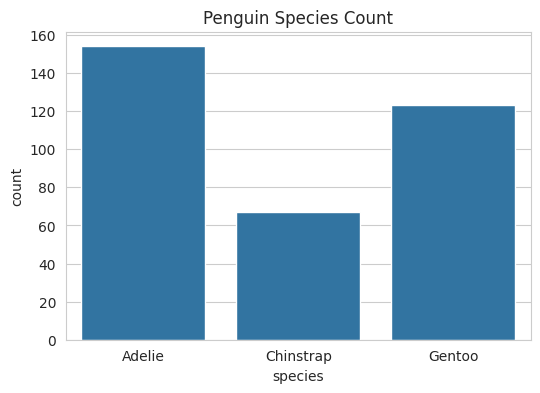

In [72]:
# Univariate Analysis
# 1. Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=df)
plt.title("Penguin Species Count")
plt.show()

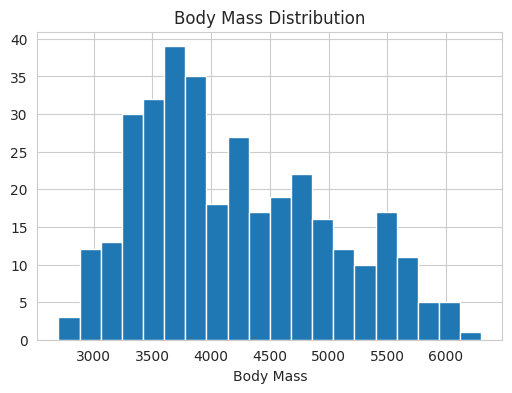

In [73]:
# 2. Histogram
plt.figure(figsize=(6,4))
plt.hist(df['body_mass_g'], bins=20)
plt.title("Body Mass Distribution")
plt.xlabel("Body Mass")
plt.show()

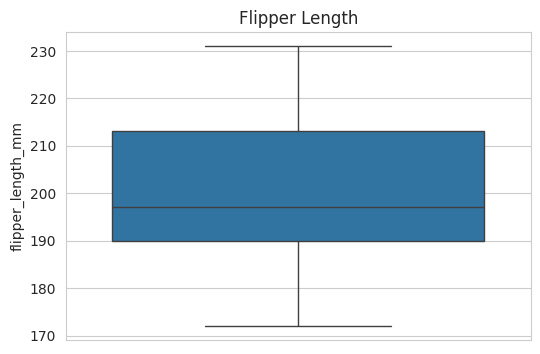

In [74]:
# 3. Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(y=df['flipper_length_mm'])
plt.title("Flipper Length")
plt.show()

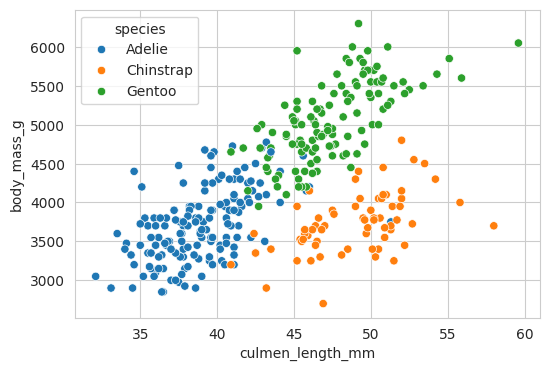

In [75]:
# Bivariate Analysis
# 1. Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='culmen_length_mm',
    y='body_mass_g',
    hue='species',
    data=df
)
plt.show()

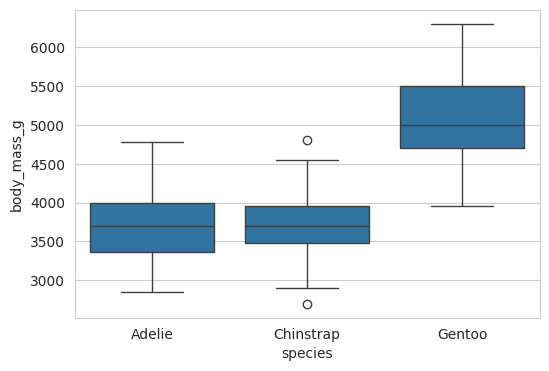

In [76]:
# 2. Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(
    x='species',
    y='body_mass_g',
    data=df
)
plt.show()

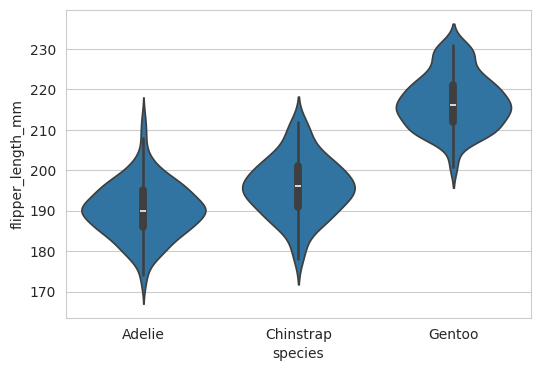

In [77]:
# 3. Violin Plot
plt.figure(figsize=(6,4))
sns.violinplot(
    x='species',
    y='flipper_length_mm',
    data=df
)
plt.show()

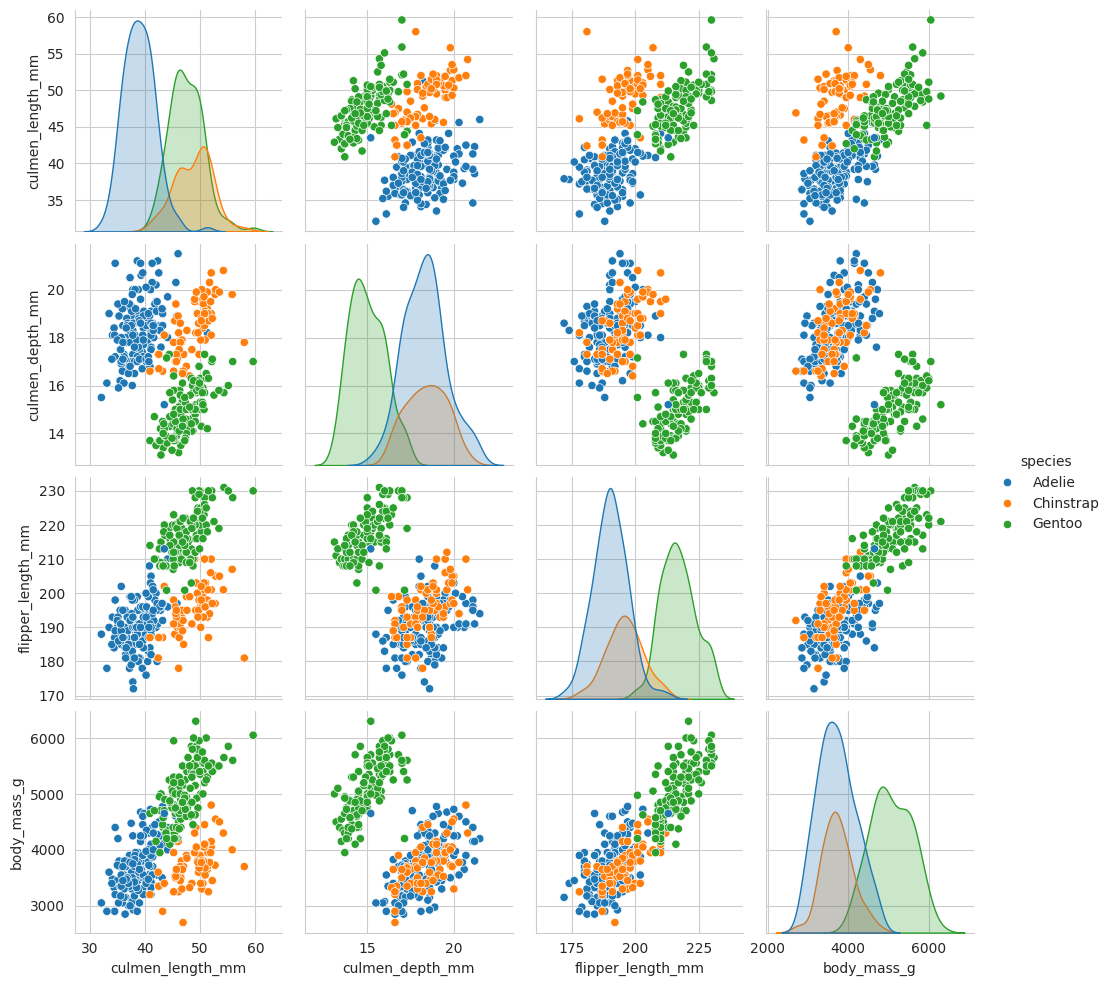

In [78]:
# Multivariate Analysis
# 1. Pair Plot

sns.pairplot(
    df[
        ['culmen_length_mm',
         'culmen_depth_mm',
         'flipper_length_mm',
         'body_mass_g',
         'species']
    ],
    hue='species'
)

plt.show()

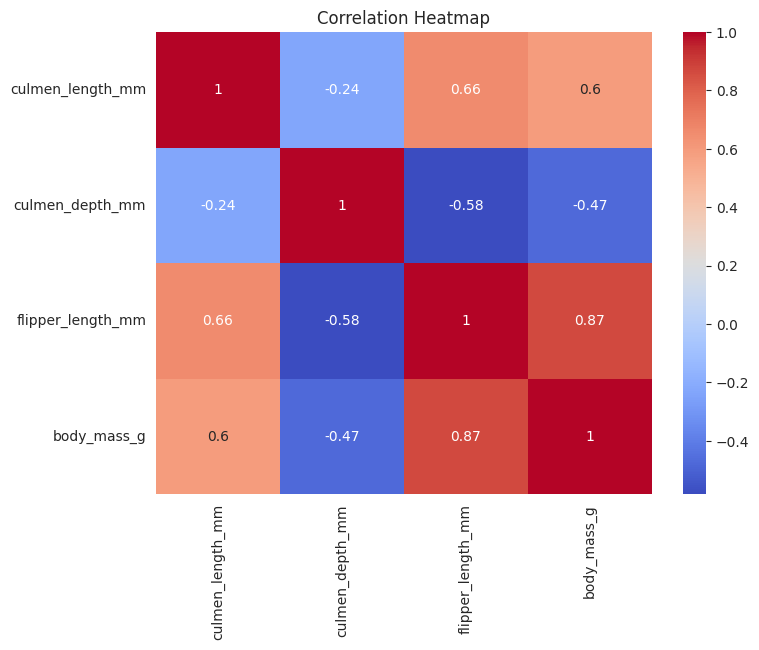

In [79]:
# 2. Heatmap
plt.figure(figsize=(8,6))

corr = df[
    ['culmen_length_mm',
     'culmen_depth_mm',
     'flipper_length_mm',
     'body_mass_g']
].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

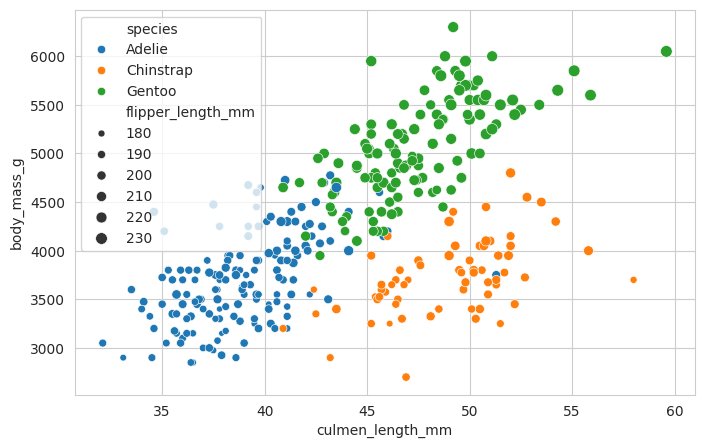

In [80]:
# 3. Scatter Plot with Multiple Variables
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='culmen_length_mm',
    y='body_mass_g',
    hue='species',
    size='flipper_length_mm',
    data=df
)

plt.show()

# Phase II - Statistical Analysis and Clustering

This phase includes 1D, 2D and 3D statistical analysis, K-Means clustering, and Hierarchical clustering.

1D Statistical Analysis

In [81]:
# 1D Statistical Analysis

numeric_cols = [
    'culmen_length_mm',
    'culmen_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

stats_1d = pd.DataFrame({
    'Count': df[numeric_cols].count(),
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Minimum': df[numeric_cols].min(),
    'Maximum': df[numeric_cols].max(),
    'Range': df[numeric_cols].max() - df[numeric_cols].min(),
    'Variance': df[numeric_cols].var(),
    'Standard Deviation': df[numeric_cols].std(),
    'Q1': df[numeric_cols].quantile(0.25),
    'Q3': df[numeric_cols].quantile(0.75),
    'IQR': df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25),
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurt()
})

stats_1d

,Count,Mean,Median,Mode,Minimum,Maximum,Range,Variance,Standard Deviation,Q1,Q3,IQR,Skewness,Kurtosis
culmen_length_mm,344,43.921930,44.25,41.1,32.1,59.6,27.5,29.633252,5.443643,39.275,48.5,9.225,0.053272,-0.863480
culmen_depth_mm,344,17.151170,17.30,17.0,13.1,21.5,8.4,3.877069,1.969027,15.600,18.7,3.100,-0.143880,-0.894497
flipper_length_mm,344,200.873900,197.00,190.0,172.0,231.0,59.0,195.998769,13.999956,190.000,213.0,23.000,0.354139,-0.959037
body_mass_g,344,4201.754386,4050.00,3800.0,2700.0,6300.0,3600.0,639381.041890,799.613058,3550.000,4750.0,1200.000,0.471690,-0.705771


1D Analysis of Categorical Variables

In [82]:
# Frequency Distribution of Categorical Variables

categorical_cols = ['species', 'island', 'sex']

for col in categorical_cols:
    print("\n", col.upper())
    print(df[col].value_counts())
    print("\nPercentage:")
    print(df[col].value_counts(normalize=True) * 100)


 SPECIES
species
Adelie       154
Gentoo       123
Chinstrap     67
Name: count, dtype: int64

Percentage:
species
Adelie       44.767442
Gentoo       35.755814
Chinstrap    19.476744
Name: proportion, dtype: float64

 ISLAND
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

Percentage:
island
Biscoe       48.837209
Dream        36.046512
Torgersen    15.116279
Name: proportion, dtype: float64

 SEX
sex
MALE      179
FEMALE    165
Name: count, dtype: int64

Percentage:
sex
MALE      52.034884
FEMALE    47.965116
Name: proportion, dtype: float64


1D Distribution Plot

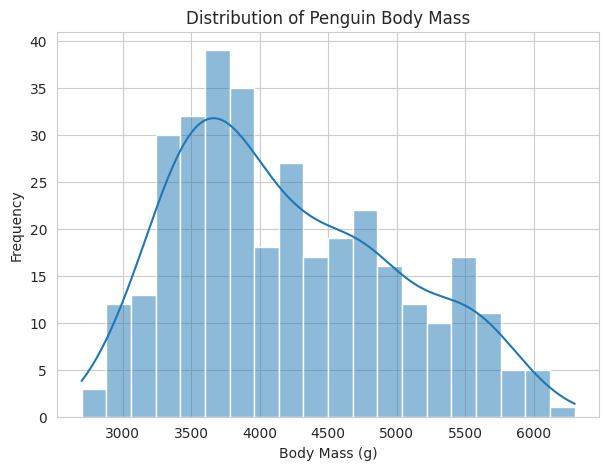

In [83]:
# Distribution of Body Mass

plt.figure(figsize=(7,5))

sns.histplot(
    df['body_mass_g'],
    bins=20,
    kde=True
)

plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body Mass (g)")
plt.ylabel("Frequency")

plt.show()

# 2D Statistical Analysis
Covariance

In [84]:
# 2D Statistical Analysis - Covariance

covariance_matrix = df[numeric_cols].cov()

print("Covariance Matrix:")
covariance_matrix

Covariance Matrix:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,29.633252,-2.519457,49.947025,2590.398957
culmen_depth_mm,-2.519457,3.877069,-16.050413,-743.012250
flipper_length_mm,49.947025,-16.050413,195.998769,9735.285518
body_mass_g,2590.398957,-743.012250,9735.285518,639381.041890


Correlation

In [85]:
# Pearson Correlation Matrix

correlation_matrix = df[numeric_cols].corr(method='pearson')

print("Pearson Correlation Matrix:")
correlation_matrix

Pearson Correlation Matrix:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.235053,0.655380,0.595110
culmen_depth_mm,-0.235053,1.000000,-0.582248,-0.471916
flipper_length_mm,0.655380,-0.582248,1.000000,0.869645
body_mass_g,0.595110,-0.471916,0.869645,1.000000


Correlation Heatmap

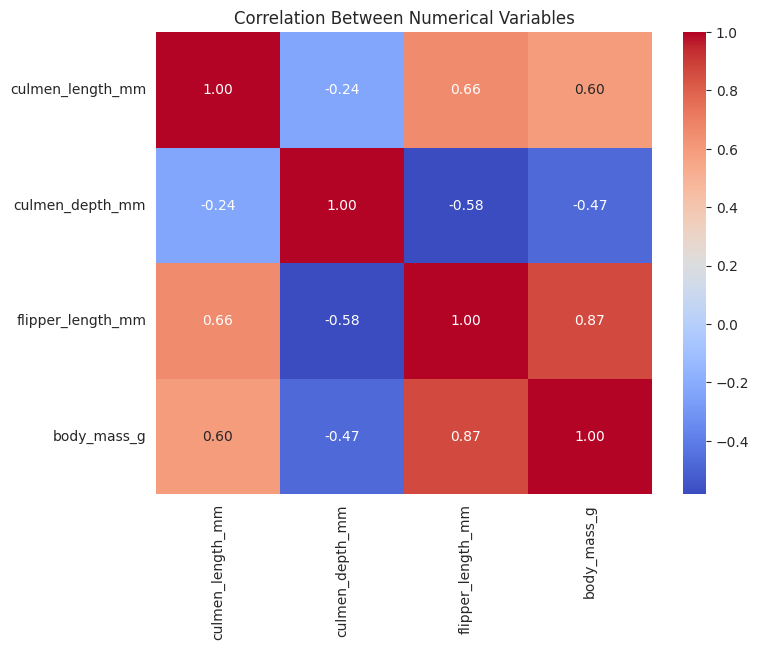

In [86]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Numerical Variables")

plt.show()

Two Numerical Variables

In [87]:
# Relationship between Culmen Length and Body Mass

from scipy.stats import pearsonr

r, p_value = pearsonr(
    df['culmen_length_mm'],
    df['body_mass_g']
)

print("Pearson Correlation:", r)
print("P-value:", p_value)

Pearson Correlation: 0.5951098244376302
P-value: 2.4524401663150915e-34


Two Categorical Variables

In [88]:
# Contingency Table - Species vs Sex

contingency_table = pd.crosstab(
    df['species'],
    df['sex']
)

contingency_table

sex,FEMALE,MALE
species,,
Adelie,74,80
Chinstrap,34,33
Gentoo,57,66


Chi-Square Test

In [89]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 0.33802061418688556
P-value: 0.8445001989987124
Degrees of Freedom: 2


Grouped Statistical Analysis

In [90]:
# Body Mass Statistics for Different Species

df.groupby('species')['body_mass_g'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
species,,,,,,
Adelie,154,3710.401003,3700.0,462.181511,2850.0,4775.0
Chinstrap,67,3732.835821,3700.0,387.230086,2700.0,4800.0
Gentoo,123,5072.371987,5000.0,508.819418,3950.0,6300.0


2D Scatter Plot

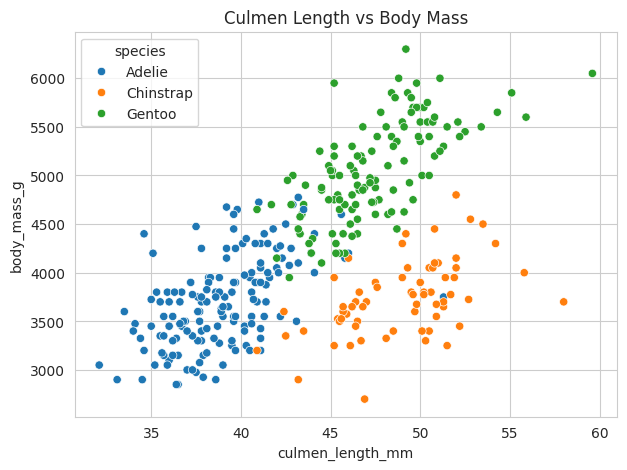

In [91]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='culmen_length_mm',
    y='body_mass_g',
    hue='species',
    data=df
)

plt.title("Culmen Length vs Body Mass")

plt.show()

# 3D Statistical Analysis

Statistics of Three Variables

In [92]:
# 3D Statistical Analysis

three_variables = [
    'culmen_length_mm',
    'flipper_length_mm',
    'body_mass_g'
]

df[three_variables].describe()

,culmen_length_mm,flipper_length_mm,body_mass_g
count,344.000000,344.000000,344.000000
mean,43.921930,200.873900,4201.754386
std,5.443643,13.999956,799.613058
min,32.100000,172.000000,2700.000000
25%,39.275000,190.000000,3550.000000
50%,44.250000,197.000000,4050.000000
75%,48.500000,213.000000,4750.000000
max,59.600000,231.000000,6300.000000


Three-Variable Correlation

In [93]:
# Correlation among three variables

df[three_variables].corr()

,culmen_length_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.00000,0.655380,0.595110
flipper_length_mm,0.65538,1.000000,0.869645
body_mass_g,0.59511,0.869645,1.000000


Three-Variable Covariance

In [94]:
# Covariance among three variables

df[three_variables].cov()

,culmen_length_mm,flipper_length_mm,body_mass_g
culmen_length_mm,29.633252,49.947025,2590.398957
flipper_length_mm,49.947025,195.998769,9735.285518
body_mass_g,2590.398957,9735.285518,639381.041890


Three-Dimensional Scatter Plot

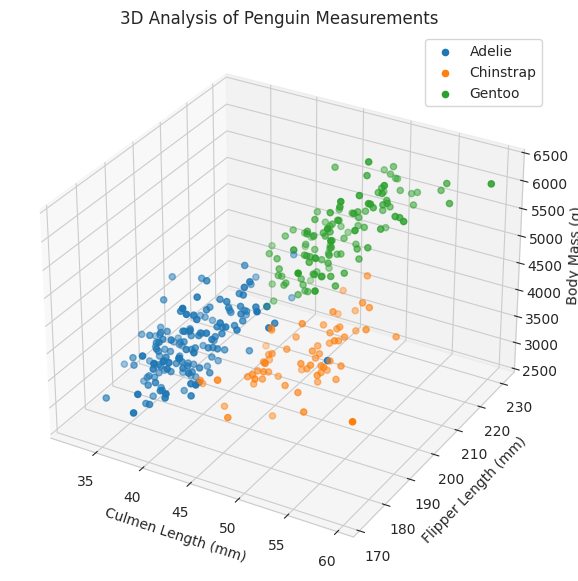

In [95]:
# 3D Scatter Plot

fig = plt.figure(figsize=(9,7))

ax = fig.add_subplot(111, projection='3d')

species_list = df['species'].unique()

for species in species_list:
    temp = df[df['species'] == species]

    ax.scatter(
        temp['culmen_length_mm'],
        temp['flipper_length_mm'],
        temp['body_mass_g'],
        label=species
    )

ax.set_xlabel("Culmen Length (mm)")
ax.set_ylabel("Flipper Length (mm)")
ax.set_zlabel("Body Mass (g)")

ax.set_title("3D Analysis of Penguin Measurements")

ax.legend()

plt.show()

Three-Variable Group Analysis

In [96]:
# Three-variable grouped analysis

df.groupby(
    ['species', 'sex']
)['body_mass_g'].agg(
    ['count', 'mean', 'median', 'std']
)

count         mean  median         std
species   sex                                           
Adelie    FEMALE     74  3386.148649  3400.0  306.190185
          MALE       80  4010.334430  3987.5  370.793467
Chinstrap FEMALE     34  3527.205882  3550.0  285.333912
          MALE       33  3944.696970  3950.0  366.185872
Gentoo    FEMALE     57  4680.263158  4700.0  284.052971
          MALE       66  5411.011430  5475.0  406.384906

# K-Means Clustering

Prepare Data

In [97]:
# Features used for clustering

cluster_features = [
    'culmen_length_mm',
    'culmen_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

X = df[cluster_features].copy()

X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,39.10000,18.70000,181.0000,3750.000000
1,39.50000,17.40000,186.0000,3800.000000
2,40.30000,18.00000,195.0000,3250.000000
3,43.92193,17.15117,200.8739,4201.754386
4,36.70000,19.30000,193.0000,3450.000000


Standardization

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardized data shape:", X_scaled.shape)

Standardized data shape: (344, 4)


Elbow Method

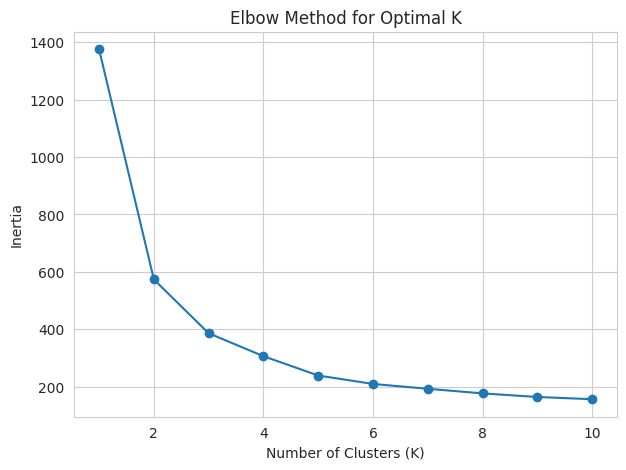

In [99]:
from sklearn.cluster import KMeans

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

Apply K-Means

In [100]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

df[
    ['species',
     'culmen_length_mm',
     'culmen_depth_mm',
     'flipper_length_mm',
     'body_mass_g',
     'KMeans_Cluster']
].head()

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,KMeans_Cluster
0,Adelie,39.10000,18.70000,181.0000,3750.000000,0
1,Adelie,39.50000,17.40000,186.0000,3800.000000,0
2,Adelie,40.30000,18.00000,195.0000,3250.000000,0
3,Adelie,43.92193,17.15117,200.8739,4201.754386,2
4,Adelie,36.70000,19.30000,193.0000,3450.000000,0


K-Means Cluster Counts

In [101]:
print("K-Means Cluster Distribution:")

print(df['KMeans_Cluster'].value_counts().sort_index())

K-Means Cluster Distribution:
KMeans_Cluster
0    132
1    123
2     89
Name: count, dtype: int64


Silhouette Score

In [102]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(
    X_scaled,
    df['KMeans_Cluster']
)

print("K-Means Silhouette Score:", kmeans_silhouette)

K-Means Silhouette Score: 0.4426051361509356


K-Means vs Actual Species

In [103]:
pd.crosstab(
    df['species'],
    df['KMeans_Cluster'],
    rownames=['Actual Species'],
    colnames=['K-Means Cluster']
)

K-Means Cluster,0,1,2
Actual Species,,,
Adelie,127,1,26
Chinstrap,5,0,62
Gentoo,0,122,1


K-Means Visualization using PCA

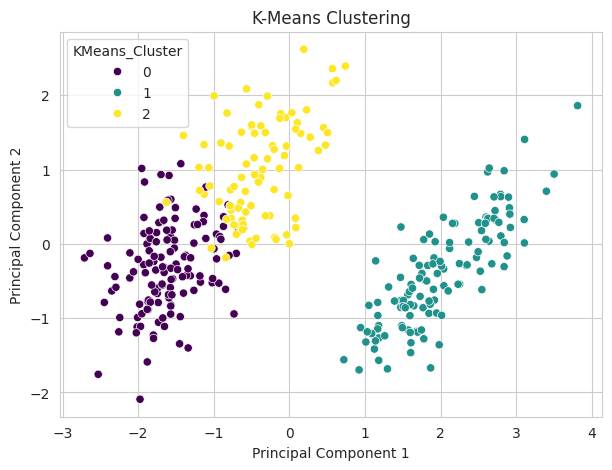

In [104]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['KMeans_Cluster'],
    palette='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering")

plt.show()

# Hierarchical Clustering

Dendrogram

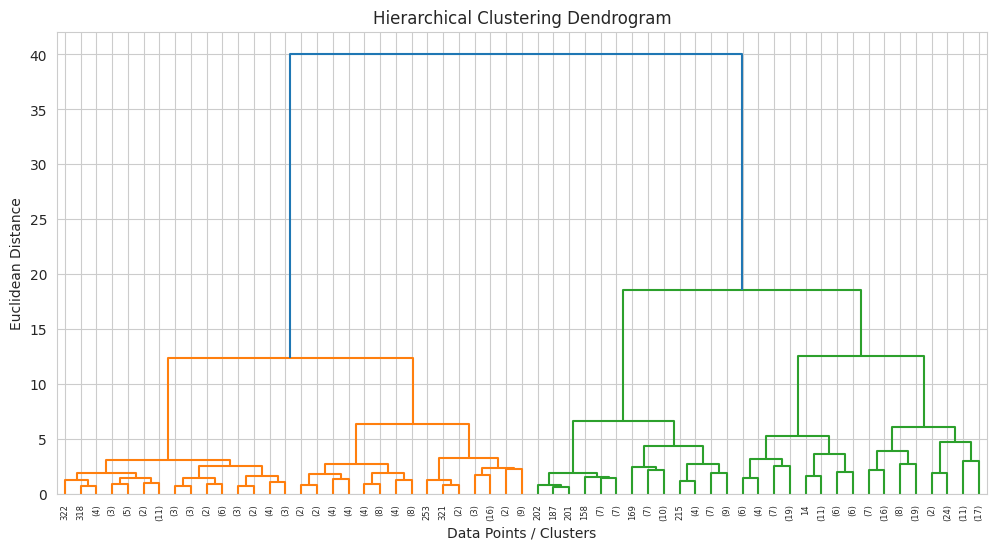

In [105]:
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_matrix = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points / Clusters")
plt.ylabel("Euclidean Distance")

plt.show()

Apply Hierarchical Clustering

In [106]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

df['Hierarchical_Cluster'] = hierarchical.fit_predict(
    X_scaled
)

df[
    ['species', 'Hierarchical_Cluster']
].head()

,species,Hierarchical_Cluster
0,Adelie,0
1,Adelie,0
2,Adelie,0
3,Adelie,0
4,Adelie,0


Hierarchical Cluster Counts

In [107]:
print("Hierarchical Cluster Distribution:")

print(
    df['Hierarchical_Cluster']
    .value_counts()
    .sort_index()
)

Hierarchical Cluster Distribution:
Hierarchical_Cluster
0    164
1    123
2     57
Name: count, dtype: int64


Hierarchical Silhouette Score

In [108]:
hierarchical_silhouette = silhouette_score(
    X_scaled,
    df['Hierarchical_Cluster']
)

print(
    "Hierarchical Clustering Silhouette Score:",
    hierarchical_silhouette
)

Hierarchical Clustering Silhouette Score: 0.44952205587019817


Actual Species vs Hierarchical Clusters

In [109]:
pd.crosstab(
    df['species'],
    df['Hierarchical_Cluster'],
    rownames=['Actual Species'],
    colnames=['Hierarchical Cluster']
)

Hierarchical Cluster,0,1,2
Actual Species,,,
Adelie,152,1,1
Chinstrap,11,0,56
Gentoo,1,122,0


Hierarchical Clustering Visualization

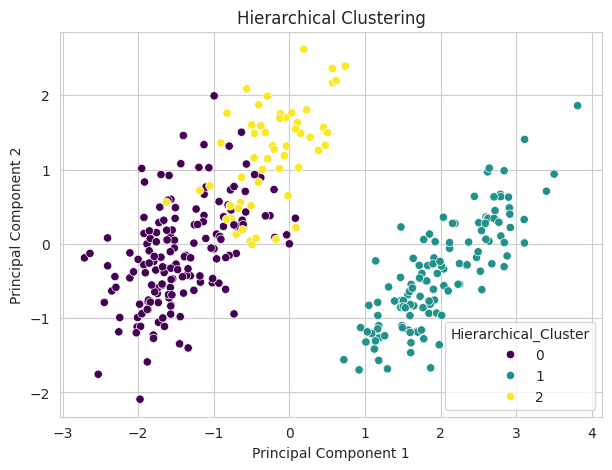

In [110]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['Hierarchical_Cluster'],
    palette='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering")

plt.show()

Final Comparison

In [111]:
comparison = pd.DataFrame({
    'Clustering Method': [
        'K-Means',
        'Hierarchical'
    ],
    'Number of Clusters': [
        3,
        3
    ],
    'Silhouette Score': [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

comparison

,Clustering Method,Number of Clusters,Silhouette Score
0,K-Means,3,0.442605
1,Hierarchical,3,0.449522
